# Fund Workstation

## Pre-Analysis Loading

#### Environment Setting

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds, rerun_no_perf_files, continue_running

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT CHINA','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['EUREKAHEDGE WORLD', 'MSCI CHINA',	'MSCI WORLD', 'EUREKAHEDGE ASIA', 'TOPIX', 'S&P 500', 'SOX', 'KOSPI', 'TAIEX', 'MSCI EM', 'RUSSELL 2000', 'STOXX 600', 'STOXX 50', 'FTSE UK', 'US HEALTHCARE', 'US FINANCIAL', 'US ENERGY', 'COMMODITY']

In [2]:
from dotenv import load_dotenv
from pathlib import Path
load_dotenv(Path("src/fofproject/.env"))


True

#### Load Data via .json

In [3]:
test = load_saved_json(folder_path="input/marex")
funds = init_funds(test)


In [ ]:
port = load_saved_json(folder_path="input/individual investigation")
funds = init_funds(port)


#### Load Data via .csv

In [4]:
# Use for manually update csv data of our portfolio and indices and merge with json file
portfolios = input_monthly_returns(r"RETURN DATA.csv")
funds = merge_funds(portfolios, funds)

In [5]:
# Use for manually input unparsable pdf data and merge with json file 
manual_csv = input_monthly_returns(r"MANUAL INPUTS.csv")
funds = merge_funds( manual_csv, funds)

NameError: name 'funds' is not defined

#### GPT Input Factsheet

##### Parse Everything

In [3]:
# Do not open the pdf while running, or the renaming process will encounter error
gpt_fund = process_pdfs_in_folder(folder_path="input/greenwoods", save=True)
funds = init_funds(gpt_fund)

Processing: input/greenwoods/GREENWOODS HARMONY_parsed from_景林平稳基金2025年12月月报.pdf


KeyboardInterrupt: 

##### Continue Running Unparsed

In [4]:
gpt_fund_2 = continue_running(folder_path="input/greenwoods", save=True)
gpt_fund_2 = init_funds(gpt_fund_2)

Processing: input/greenwoods/金色中国基金2025年12月月报.pdf
YTD cross-validation (金色中国, 2019): compound=0.473126 vs YTD=0.473400 (error=0.000274, likely minor OCR discrepancy)
YTD cross-validation (金色中国, 2017): compound=0.521138 vs YTD=0.005211 (error=0.515927, likely minor OCR discrepancy)
YTD cross-validation (金色中国, 2009): compound=1.483587 vs YTD=0.014835 (error=1.468752, likely minor OCR discrepancy)
YTD cross-validation (金色中国, 2008): compound=-0.555678 vs YTD=-0.005557 (error=0.550121, likely minor OCR discrepancy)
YTD cross-validation (金色中国, 2007): compound=1.002622 vs YTD=0.010029 (error=0.992593, likely minor OCR discrepancy)
YTD cross-validation (金色中国, 2006): compound=0.924097 vs YTD=0.009241 (error=0.914856, likely minor OCR discrepancy)


In [8]:
funds = gpt_fund_2 | funds

##### Re-Run No Performance Funds

In [4]:
# Target the files with "No Performance Found", and re-run the analysis again
gpt_fund_2 = rerun_no_perf_files(folder_path="input/greenwoods", save=True)

No entries found in No Performance Found.txt.


#### Merging Different Input

In [ ]:
# Use the left hand's PERFORMANCE TABLE to update the right hand one
funds = merge_funds(portfolio_csv, funds)

In [4]:
# Right-hand side has higher priority
funds = funds | test

#### Save the Changes to .json & .csv

In [ ]:
# Careful what fund you are saving to what folder
save_changes_in_fund(funds, folder_path="input/worth_a_look")

In [ ]:
print(funds['ASIAN TECHNOLOGY'].total_max_dd)

## Fund Analysis

#### Dataframe Comparison

In [6]:
df = compare_funds(funds)
do_not_display = our_index + our_portfolio
df = df[~df["Name"].isin(do_not_display)].reset_index(drop=True)
print(df)


                Name One Liner Geo Focus Strategy Asset Class Identifier  \
0         GOODLANDER      None      None     None        None       None   
1      FRONTIER ROAD      None      None     None        None       None   
2              ASPEN      None      None     None        None       None   
3               BWCP      None      None     None        None       None   
4       ASPEN GLOBAL      None      None     None        None       None   
5            METRICA      None      None     None        None       None   
6        ALBA CREDIT      None      None     None        None       None   
7          GEMBRIDGE      None      None     None        None       None   
8            CANDELO      None      None     None        None       None   
9   FLOATING CAPITAL      None      None     None        None       None   
10          FRONTIER      None      None     None        None       None   
11              WAHA      None      None     None        None       None   
12         H

In [ ]:
# Column List = ["Name", "One Liner", "Geo Focus", "Strategy", "Asset Class", "Identifier", "IR Contact", "AUM (in Mn USD)", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", "Month Running",
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]

In [7]:
# sort by what we think important   
df = df.sort_values(by=["Sharpe Ratio", "Annualized Return"], ascending=[False, False])
# mask and filtered only the wanted funds
mask =  (df["Month Running"] > 6) & (df["Annualized Return"] > 0.12)
df['Worth a Look'] = mask
# Display only the following columns
display_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","One Liner","Max Drawdown" ]]
display_df


,Worth a Look,Name,Sharpe Ratio,Annualized Return,AUM (in Mn USD),Month Running,One Liner,Max Drawdown
9,True,FLOATING CAPITAL,1.925754,0.376585,60,22.333333,None,0.066215
2,True,ASPEN,1.895469,0.545223,50,22.333333,None,0.128085
0,True,GOODLANDER,1.758503,0.219232,218,43.600000,None,0.086066
1,True,FRONTIER ROAD,1.727715,0.332435,0,59.833333,None,0.321607
12,True,HYPERNOVA,1.275541,0.180853,402,56.766667,None,0.148637
3,True,BWCP,1.194662,0.139783,171,69.000000,None,0.178967
5,False,METRICA,0.812860,0.072785,49,100.466667,None,0.204993
7,False,GEMBRIDGE,0.782913,0.079635,30,71.000000,None,0.220932
8,False,CANDELO,0.421277,0.072285,160,69.000000,None,0.293883
4,False,ASPEN GLOBAL,NaN,NaN,0,NaN,None,NaN


#### Save it to CSV

In [ ]:
# Select the column you want to save
output_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Max Drawdown" ,"Net Exposure","Strategy", "Sector","Contact","Description", "Mgmt Fee", "Perf Fee"]]
output_df.to_csv("output/funds_comparison.csv", index=False)

#### Save it to a list

In [ ]:
exclude_list = our_index + our_portfolio
df = df[~df["Name"].isin(exclude_list)].reset_index(drop=True)
worth_looking = df.loc[df["Worth a Look"], "Name"].tolist()
print(worth_looking)

#### Compare Performance Table

In [ ]:
funds['ONELS'].export_monthly_table(benchmark_fund = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)

#### Plot Cumulative Return

In [17]:

funds_to_be_plot = subset_of_funds(funds, ['S&P 500', 'RDGFF', 'US FINANCIAL'])
start_month = "2022-12"
end_month = "2023-9"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False,
    save=False,
    toggle=False
    )


#### Correlation Heat Map

In [ ]:
# Correlation heatmap
funds_to_be_plot = subset_of_funds(funds, ['QUANTICA', 'RDGFF', 'HAO','US FINANCIAL'])
start_month = "2019-12"
end_month = "2025-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12, save=True)
fig.show()

#### Efficient Frontier Analysis

In [18]:
remove_list = ['RDGFF', 'E20']

for i, k in enumerate(our_portfolio):
    if k in remove_list:
        our_portfolio.pop(i)
test =  ['RDGFF', 'QUANTICA']
print(our_portfolio)


funds_to_be_plot = subset_of_funds(funds, test)
print(len(funds))

['TAIREN', 'HAO', 'LEXINGTON', 'LIM', 'FOREST', 'WT CHINA', '3W GLOBAL', '3W CHINA', '3W HEALTHCARE', 'TIMEFOLIO', 'MONOLITH', 'PERSEVERANCE', 'NEO IVY', 'JH BIOTECH']
46


In [ ]:
# Choose Mode between "Maximum Sharpe", "Minimum Variance", "Target Return"
fig, weights, stats = minimum_variance_analysis(funds=funds_to_be_plot, mode="Maximum Sharpe", title=None)
print(weights)
print(stats)

#### Summary of a Fund

The fund employs a thematic, equity-biased absolute return strategy focused on asymmetric investment opportunities, aiming for strong risk-adjusted returns through macro-driven themes and rigorous risk management.
Net Exposure = 47.0% to 47.0%
No contact info
Chart saved to ARNOTT OPPORTUNITIES_vs_S&P 500_Fund Performance on Benchmark's Worst Days.png


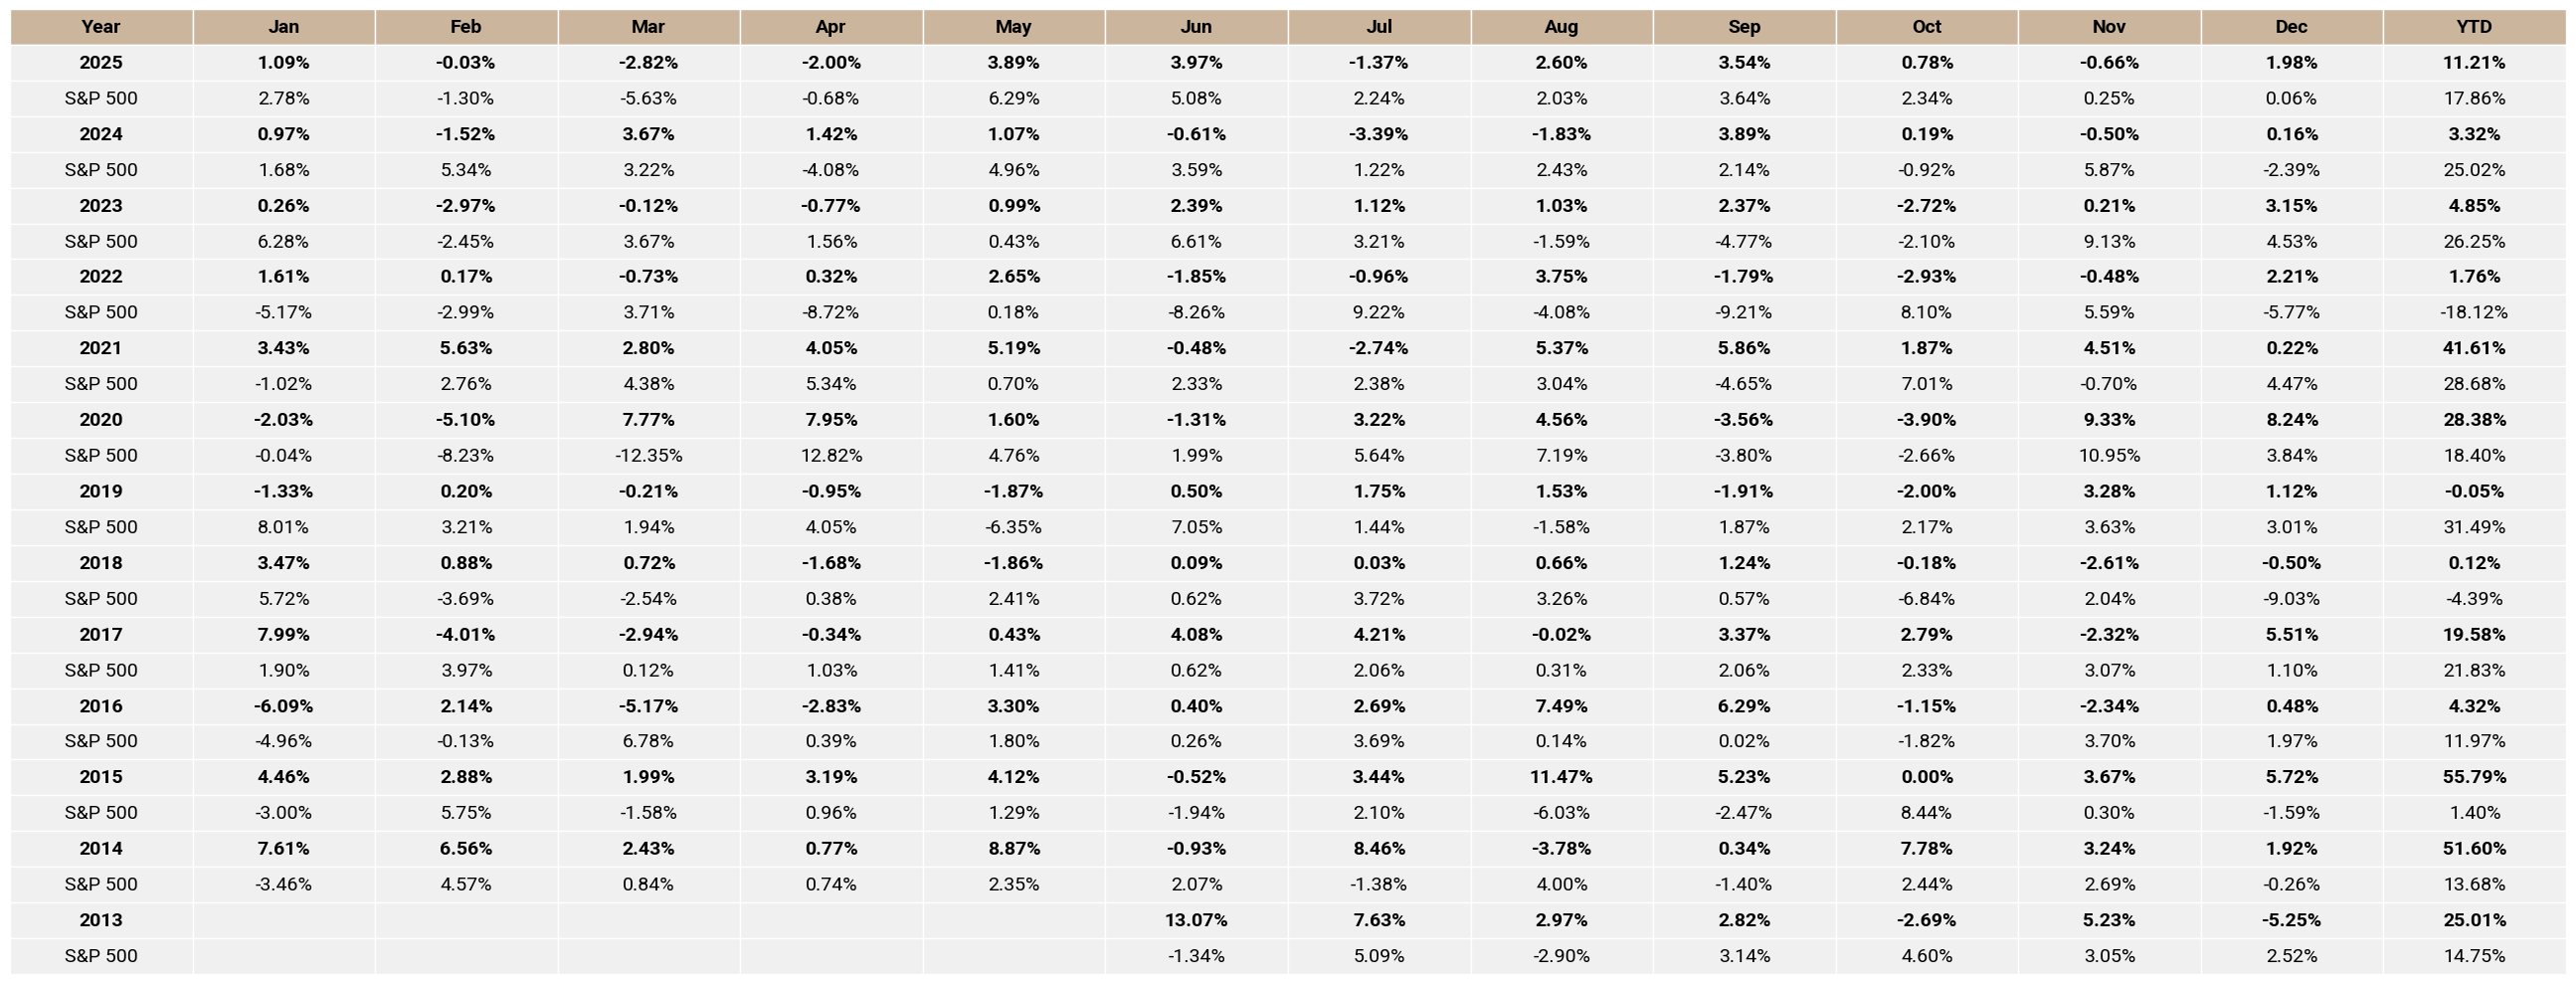

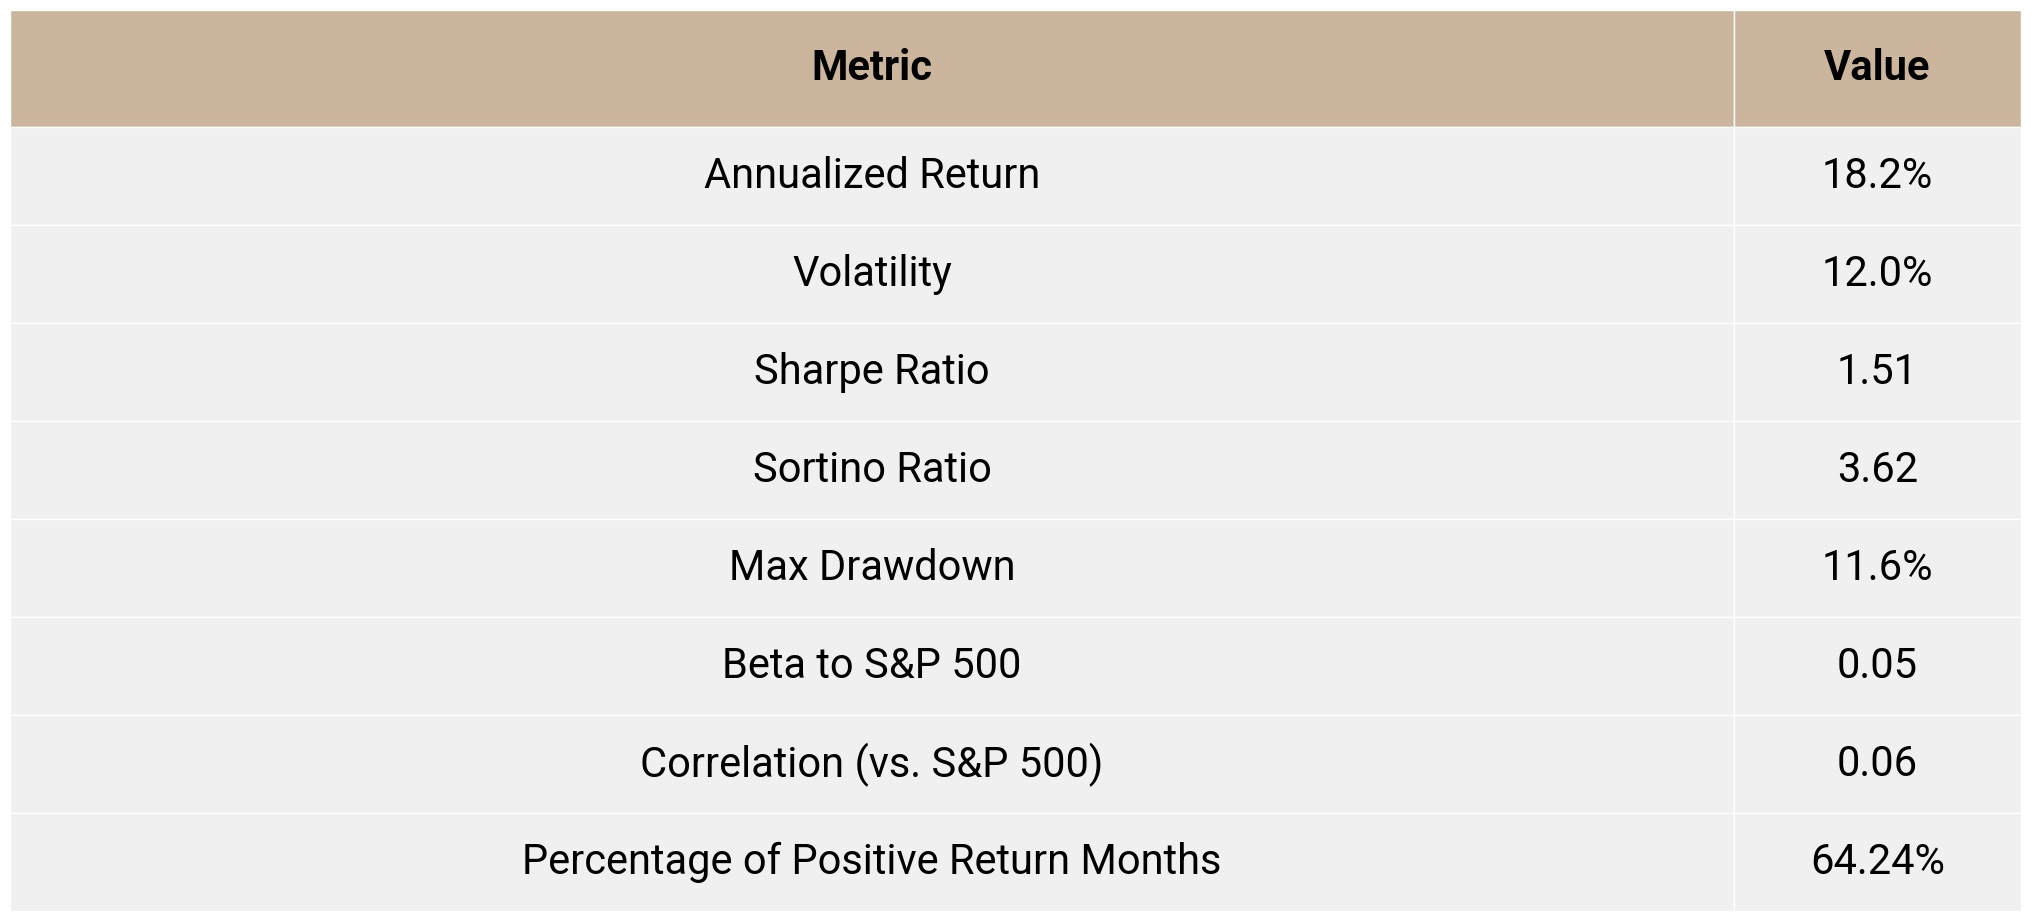

/workspaces/fofproject/src/fofproject/fund.py:2353: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



Chart saved to ARNOTT OPPORTUNITIES_vs_RDGFF_Performance during our fund's top 10 drawdowns.png
Chart saved to ARNOTT OPPORTUNITIES_vs_S&P 500_Entire performance compared with our fund's.png


In [14]:
# our_index = ['EUREKAHEDGE WORLD', 'MSCI CHINA',	'MSCI WORLD', 'EUREKAHEDGE ASIA', 'TOPIX', 'S&P 500', 'SOX', 'KOSPI', 'TAIEX', 'MSCI EM', 'RUSSELL 2000', 'STOXX 600', 'STOXX 50', 'FTSE UK', 'US HEALTHCARE', 'US FINANCIAL', 'US ENERGY', 'COMMODITY']
fund_name = 'ARNOTT OPPORTUNITIES'
funds[fund_name].summary_of_a_fund(benchmark_fund=funds['S&P 500'],language="en",save=True)
funds[fund_name].compare_worst_performance(funds['RDGFF'], title="Performance during our fund's top 10 drawdowns", n_worst=10,  save=True)
funds[fund_name].compare_worst_performance(funds['S&P 500'], title="Entire performance compared with our fund's" ,n_worst=100,  save=True)

#### Correlation Deep Dive

In [13]:
# fund_name = 'FOREST STD'
funds_to_be_plot = subset_of_funds(funds, [fund_name] + our_index)
fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12, save=True)
fig.show()

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]



fig1 = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )

fig2 = compa